# Eksperyment pierwszy
Eksperyment, w którym definiujemy dwa zbiory z różnicami w wielkości komórek. Utworzone zostaną dwa zbiory z różnicą w rozmiarze komórek w zbiorze testowym. Ma to na celu sprawdzenie czy istnieje
różnica w MSE

In [1]:
from builders.simple_generator import generate_image, generate_batch
from src.builders.image_builder import ImageGenerator
from src.utils.classes.config import GenerationConfig

conf1 = GenerationConfig()
conf1.distribution.algorithm = 'clustered'
komorka1 = ImageGenerator(conf1)

conf = GenerationConfig()
conf.axes.mean_x = 22
conf.axes.mean_y = 16
conf.axes.std_x = 6

conf.distribution.algorithm = 'clustered'

komorka2 = ImageGenerator(conf)




In [2]:
tranning_set1 = komorka1.build_batch(5000)
validaion_set1 = komorka1.build_batch(1000)
normal_size_set1 = komorka1.build_batch(2000)

large_size_set1 = komorka2.build_batch(2000)

Generated 8 centers
Generated 6 centers
Generated 7 centers
Generated 5 centers
Generated 8 centers
Generated 9 centers
Generated 8 centers
Generated 9 centers
Generated 8 centers
Generated 5 centers
Generated 7 centers
Generated 5 centers
Generated 6 centers
Generated 7 centers
Generated 6 centers
Generated 7 centers
Generated 9 centers
Generated 4 centers
Generated 4 centers
Generated 8 centers
Generated 6 centers
Generated 6 centers
Generated 7 centers
Generated 7 centers
Generated 7 centers
Generated 7 centers
Generated 10 centers
Generated 9 centers
Generated 5 centers
Generated 6 centers
Generated 8 centers
Generated 8 centers
Generated 5 centers
Generated 8 centers
Generated 7 centers
Generated 11 centers
Generated 7 centers
Generated 7 centers
Generated 10 centers
Generated 6 centers
Generated 10 centers
Generated 6 centers
Generated 8 centers
Generated 6 centers
Generated 8 centers
Generated 7 centers
Generated 8 centers
Generated 6 centers
Generated 6 centers
Generated 9 cent

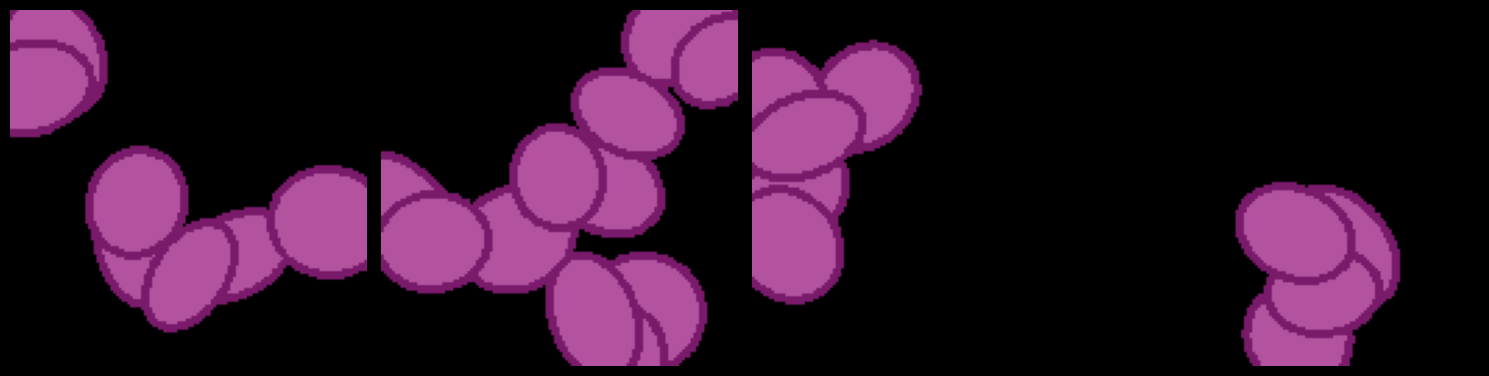

In [3]:
from src.visualization.visualize_output import show_images

show_images(tranning_set1[:4])
show_images(large_size_set1[:4])

In [4]:
import numpy as np


def preprocess(data_list):
    return np.array(data_list, dtype='float32') / 255.

x_train = preprocess(tranning_set1)
x_val = preprocess(validaion_set1)
x_test_normal1 = preprocess(normal_size_set1)
x_test_large = preprocess(large_size_set1)

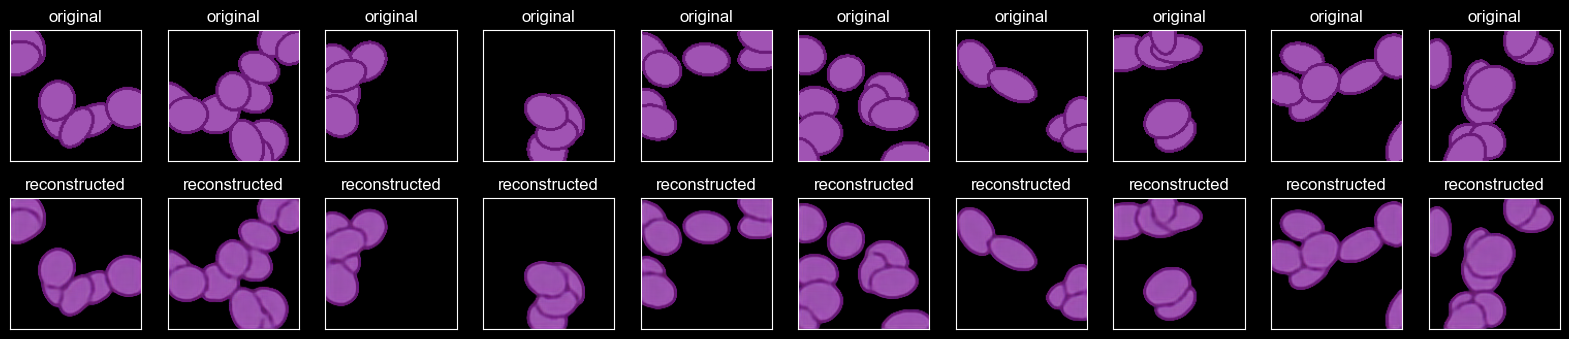

In [5]:
import keras
import numpy as np
from src.models.main import print_diag
from src.visualization.visualize_output import visualize_output
from src.models.encoder_convolutional import Encoder_conv

enkoder = Encoder_conv()

enkoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 'mse'])

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    min_delta=0.0001,
    restore_best_weights=True
)

history = enkoder.fit(
    x_train, x_train,
    epochs=50,
    shuffle=True,
    callbacks=[early_stopping],
    validation_data=(x_val, x_val),
    verbose=1
)
decoded_normal1 = enkoder.predict(x_test_normal1)
decoded_large = enkoder.predict(x_test_large)

mse_normal = enkoder.evaluate(x_test_normal1, x_test_normal1, verbose=0)[0]
mse_large = enkoder.evaluate(x_test_large, x_test_large, verbose=0)[0]

print(f"\nTrening zakończony po {len(history.history['loss'])} epokach.")
print(f"MSE Normal: {mse_normal:.6f}")
print(f"MSE Large:  {mse_large:.6f}")

visualize_output(x_test_normal1, decoded_normal1, 10)

visualize_output(x_test_large, decoded_large, 10)

Trening zakończony po 15 epokach. Wyniki błedu średniokwadratowego MSE przedstawiają się następująco:

Komórki normalne : 0,085
Komórki powiękosze: 0,24

Zauważono znacznie większy błąd w komórkach powiększonych. Jest to spowodowane inną strukturą wygenerowanych, co wprowadza zmiany w rozkładzie pikseli. Jednakże mimo wzrotsu błędu model nie utracił zdolności do poprawnej klasyfikacji kluczowych cech dla komórek.

Enkoder jest w stanie rozpoznawać komórki w podobnym kształcie, ale o różnych wymiarach.


In [6]:
import pandas as pd

temp = [{'Eksperyment': 'MSE Normal', 'Wynik': mse_normal},
        {'Eksperyment': 'MSE Large', 'Wynik': mse_large}
]

mse_dataset = pd.DataFrame(temp, columns=['Eksperyment', 'Wynik'])
mse_dataset


,Eksperyment,Wynik
0,MSE Normal,0.077137
1,MSE Large,0.232328


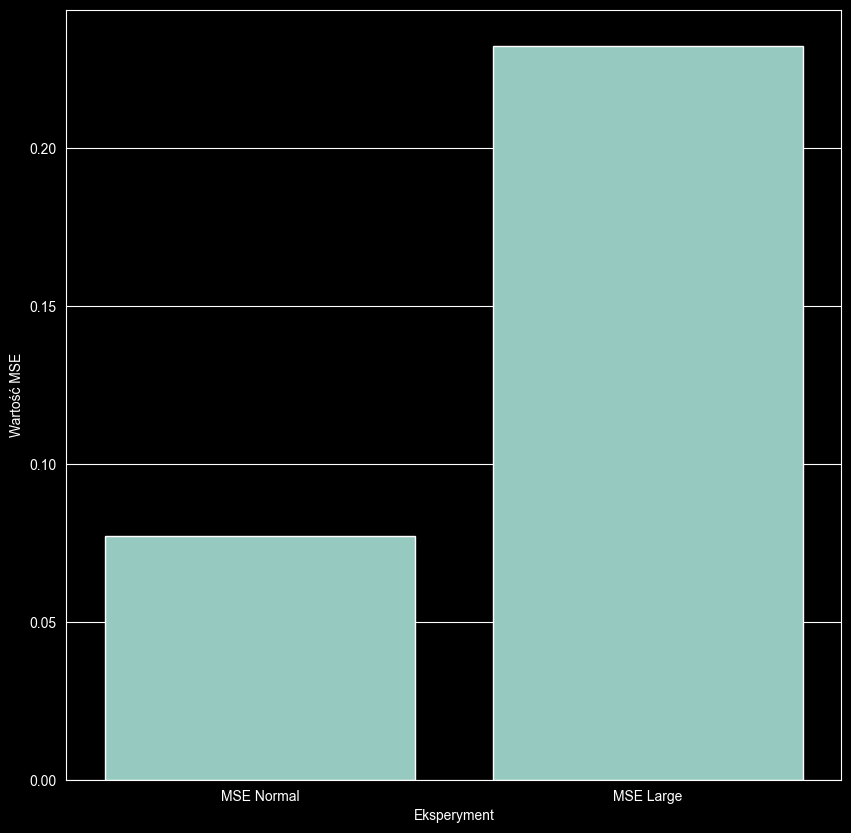

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 10))
sns.barplot(data=mse_dataset, y='Wynik',x='Eksperyment')
plt.ylabel("Wartość MSE")
plt.show()


# Eksperyment drugi
zmiana kolorów w drugim zbiorze testowym

In [8]:
from builders.simple_generator import generate_image
from src.builders.image_builder import ImageGenerator
from src.utils.classes.config import GenerationConfig
from src.builders.simple_generator import generate_batch


color_conf = GenerationConfig()
color_conf.nucleus.base_color = (134,80,34)
color_conf.nucleus.border_color = (29,40,182)
kolor_komorki = ImageGenerator(color_conf)




In [9]:
color_test_set2 = kolor_komorki.build_batch(2000)
tranning_set2 = generate_batch(5000)
validaion_set2 = generate_batch(1000)
normal_test_set2 = generate_batch(2000)

Generated 15 centers
Generated 16 centers
Generated 15 centers
Generated 15 centers
Generated 16 centers
Generated 15 centers
Generated 14 centers
Generated 15 centers
Generated 16 centers
Generated 16 centers
Generated 15 centers
Generated 13 centers
Generated 17 centers
Generated 15 centers
Generated 14 centers
Generated 14 centers
Generated 17 centers
Generated 14 centers
Generated 17 centers
Generated 18 centers
Generated 14 centers
Generated 15 centers
Generated 15 centers
Generated 13 centers
Generated 17 centers
Generated 17 centers
Generated 16 centers
Generated 15 centers
Generated 17 centers
Generated 14 centers
Generated 15 centers
Generated 13 centers
Generated 14 centers
Generated 16 centers
Generated 17 centers
Generated 14 centers
Generated 17 centers
Generated 13 centers
Generated 14 centers
Generated 17 centers
Generated 15 centers
Generated 15 centers
Generated 13 centers
Generated 15 centers
Generated 14 centers
Generated 15 centers
Generated 16 centers
Generated 16 

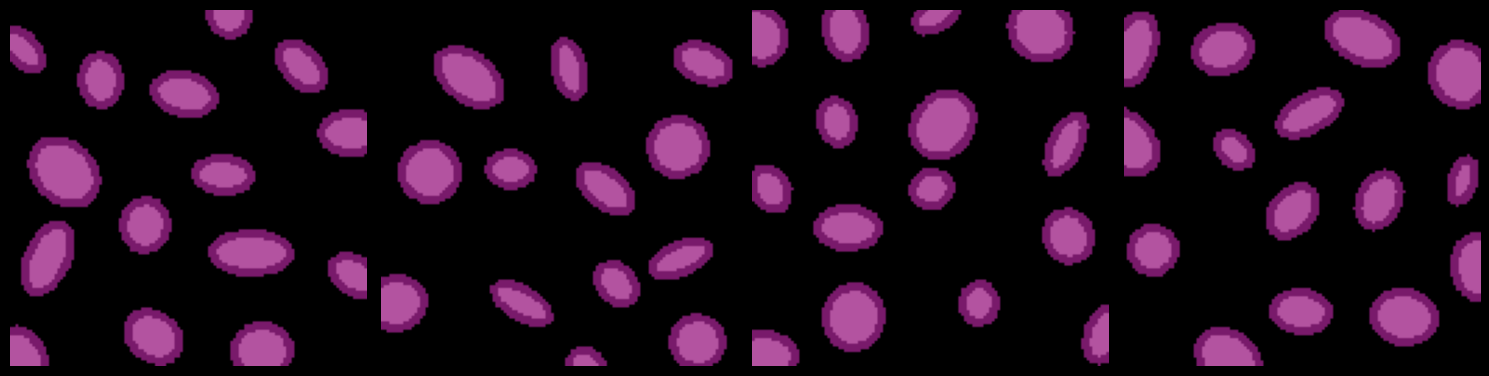

In [10]:
from src.visualization.visualize_output import show_images

show_images(color_test_set2[:4])
show_images(tranning_set2[:4])
show_images(validaion_set2[:4])

In [11]:
x_test_color = preprocess(color_test_set2)
x_test_normal2 = preprocess(normal_test_set2)
x_val_set2 = preprocess(validaion_set2)
x_training_set2 = preprocess(tranning_set2)

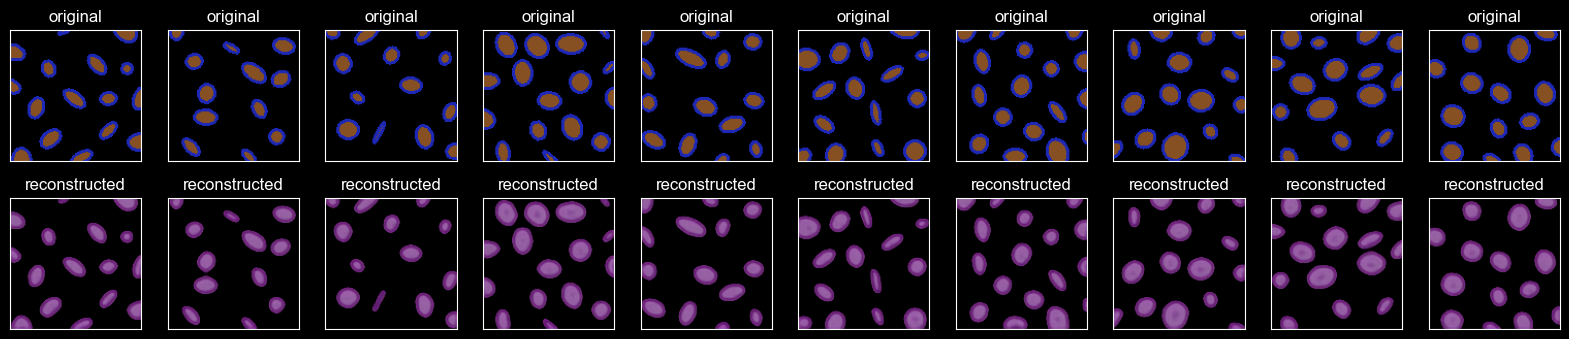

In [12]:
import keras
import numpy as np
from src.models.main import print_diag
from src.visualization.visualize_output import visualize_output
from src.models.encoder_convolutional import Encoder_conv

enkoder = Encoder_conv()

enkoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 'mse'])

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    min_delta=0.0001,
    restore_best_weights=True
)

history = enkoder.fit(
    x_training_set2, x_training_set2,
    epochs=50,
    shuffle=True,
    callbacks=[early_stopping],
    validation_data=(x_val_set2, x_val_set2),
    verbose=1
)
decoded_normal2 = enkoder.predict(x_test_normal2)
decoded_diff_col = enkoder.predict(x_test_color)

mse_normal = enkoder.evaluate(x_test_normal2, x_test_normal2, verbose=0)[0]
mse_diff_col = enkoder.evaluate(x_test_color, x_test_color, verbose=0)[0]

print(f"\nTrening zakończony po {len(history.history['loss'])} epokach.")
print(f"MSE Normal: {mse_normal:.6f}")
print(f"MSE With different color:  {mse_diff_col:.6f}")

visualize_output(x_test_normal2, decoded_normal2, 10)

visualize_output(x_test_color, decoded_diff_col, 10)

In [13]:
color_data = {'Eksperyment': 'MSE with different color', 'Wynik': [mse_diff_col]}

mse_dataset = pd.concat([mse_dataset, pd.DataFrame(color_data)], ignore_index=True)

mse_dataset

,Eksperyment,Wynik
0,MSE Normal,0.077137
1,MSE Large,0.232328
2,MSE with different color,0.175345


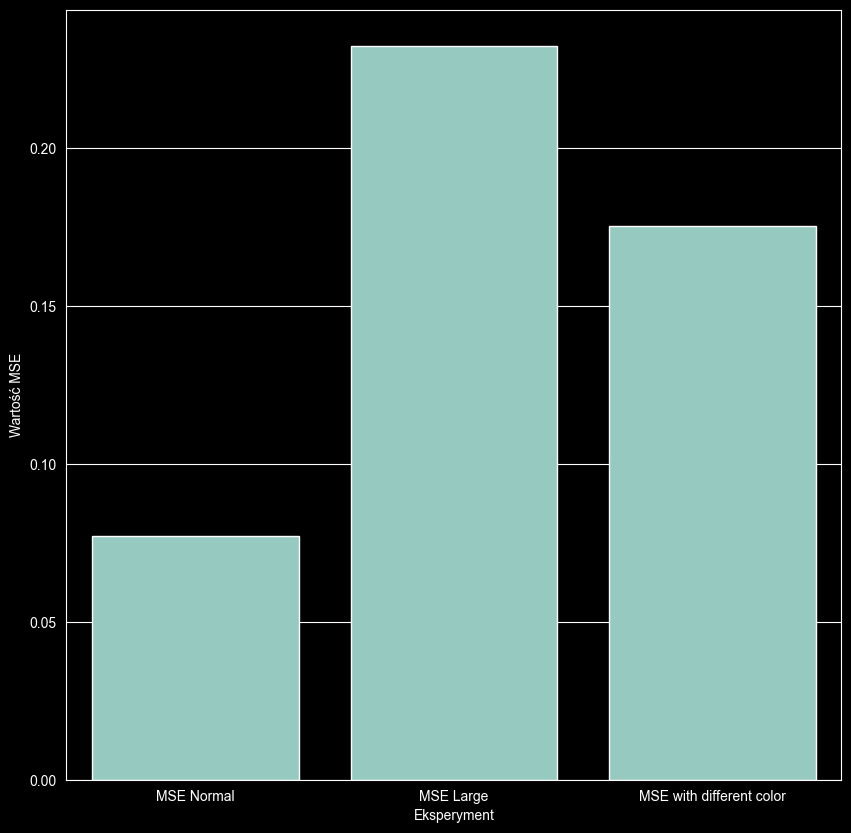

In [14]:
plt.figure(figsize=(10, 10))
sns.barplot(data=mse_dataset, y='Wynik',x='Eksperyment')
plt.ylabel("Wartość MSE")
plt.show()

Kolor komórek wpływa jeszcze w mniejszym stopniu na wynik błedu MSE niż w przypadku większych komórek. Enkoder jest w stanie rozpoznawać kolory

# Eksperyment trzeci
W ekspetymenie sprawdzony zostanie wpływ rozkładu komórek na błąd MSE


In [15]:
from builders.simple_generator import generate_image
from src.builders.image_builder import ImageGenerator
from src.utils.classes.config import GenerationConfig
from src.builders.simple_generator import generate_batch

distribution_conf = GenerationConfig()
distribution_conf.distribution.algorithm = 'gaussian'
img = ImageGenerator(distribution_conf)

In [16]:
set_trenning3 = generate_batch(5000)
validaion_set3 = generate_batch(1000)
test_set3 = generate_batch(2000)
distribution_test3 = img.build_batch(2000)

Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 

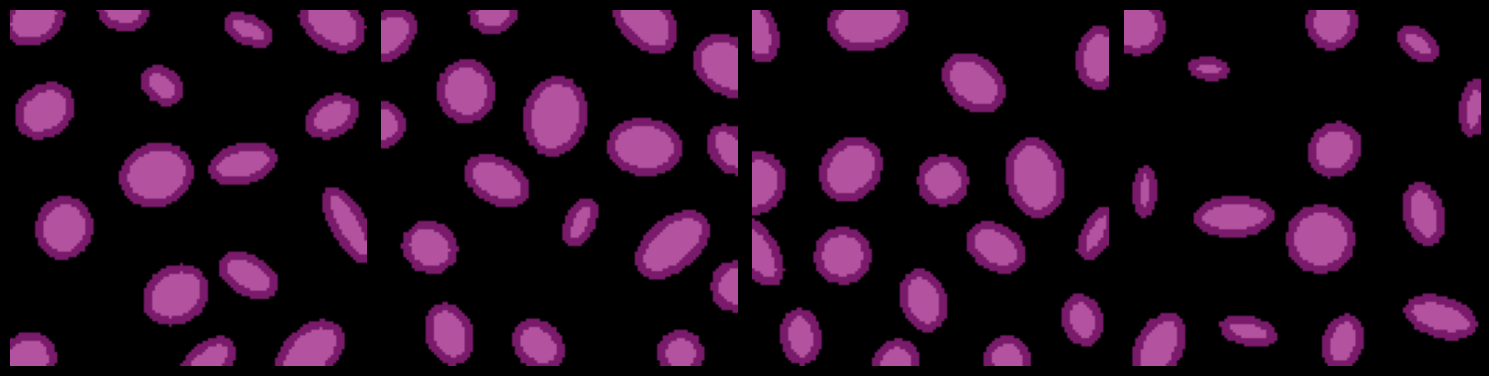

In [17]:
from src.visualization.visualize_output import show_images
show_images(distribution_test3[:4])
show_images(set_trenning3[:4])
show_images(validaion_set3[:4])

In [18]:
x_test_distribution = preprocess(distribution_test3)
x_test_normal3 = preprocess(test_set3)
x_val_set3 = preprocess(validaion_set3)
x_training_set3 = preprocess(set_trenning3)

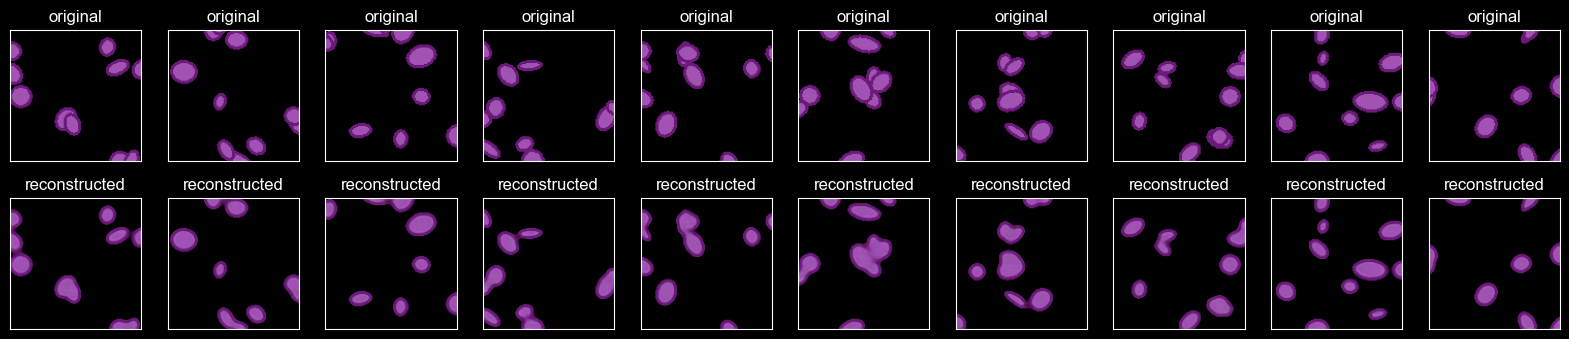

In [19]:
import keras
import numpy as np
from src.models.main import print_diag
from src.visualization.visualize_output import visualize_output
from src.models.encoder_convolutional import Encoder_conv

enkoder = Encoder_conv()

enkoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 'mse'])

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    min_delta=0.0001,
    restore_best_weights=True
)

history = enkoder.fit(
    x_training_set3, x_training_set3,
    epochs=50,
    shuffle=True,
    callbacks=[early_stopping],
    validation_data=(x_val_set3, x_val_set3),
    verbose=1
)
decoded_normal3 = enkoder.predict(x_test_normal3)
decoded_distr = enkoder.predict(x_test_distribution)

mse_normal = enkoder.evaluate(x_test_normal3, x_test_normal3, verbose=0)[0]
mse_distr = enkoder.evaluate(x_test_distribution, x_test_distribution, verbose=0)[0]

print(f"\nTrening zakończony po {len(history.history['loss'])} epokach.")
print(f"MSE Normal: {mse_normal:.6f}")
print(f"MSE with different way of distribution  {mse_distr:.6f}")

visualize_output(x_test_normal3, decoded_normal3, 10)

visualize_output(x_test_distribution, decoded_distr, 10)

In [20]:
dist_data = {'Eksperyment': 'MSE with different distribution', 'Wynik': [mse_distr]}

mse_dataset = pd.concat([mse_dataset, pd.DataFrame(dist_data)], ignore_index=True)

mse_dataset

,Eksperyment,Wynik
0,MSE Normal,0.077137
1,MSE Large,0.232328
2,MSE with different color,0.175345
3,MSE with different distribution,0.083466


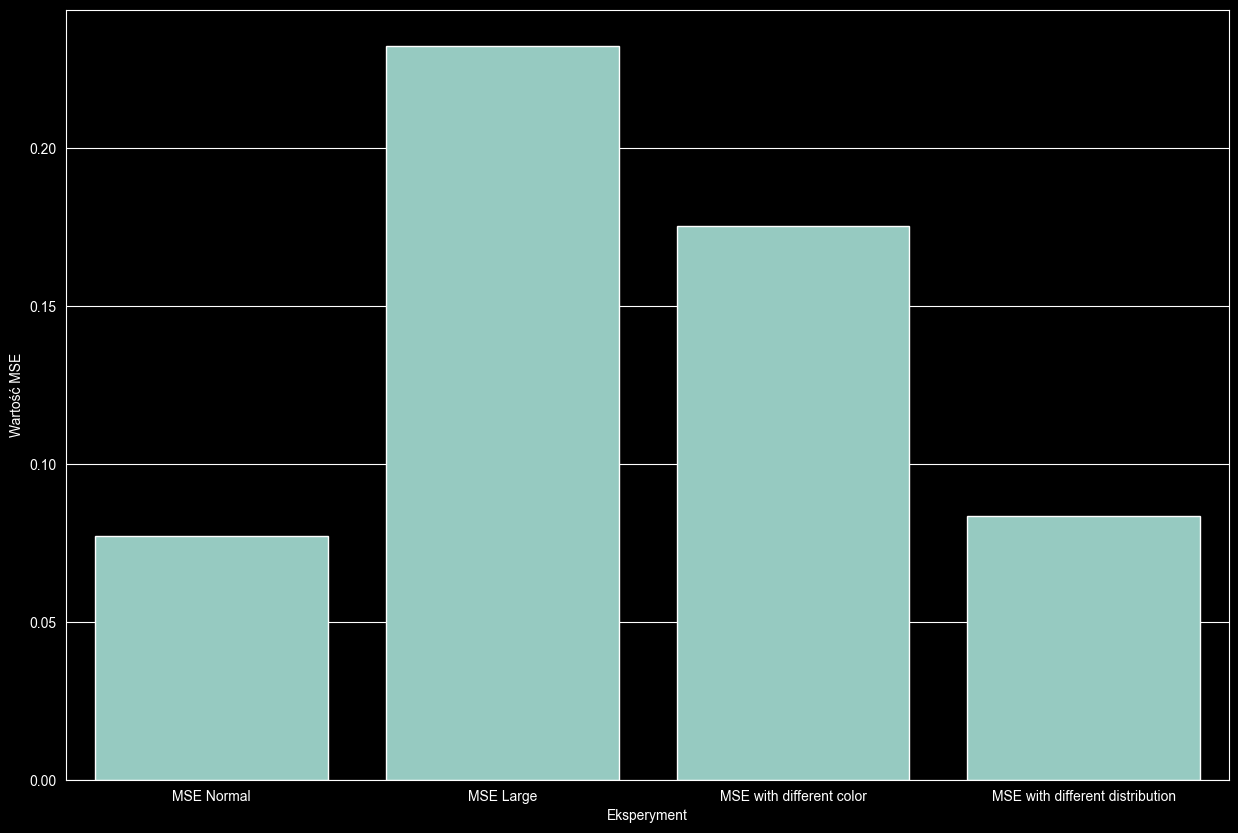

In [21]:
plt.figure(figsize=(15,10))
sns.barplot(data=mse_dataset, y='Wynik',x='Eksperyment')
plt.ylabel("Wartość MSE")
plt.show()

eksperyment


# Eksperyment czwarty

In [22]:
from builders.simple_generator import generate_image
from src.builders.image_builder import ImageGenerator
from src.utils.classes.config import GenerationConfig
from src.builders.simple_generator import generate_batch

perlin_conf = (ImageGenerator().with_perlin_noise(True))
perlin_test_set = perlin_conf.build_batch(2000)

Generated 17 centers
Generated 17 centers


In [23]:
set_trenning4 = generate_batch(5000)
validaion_set4 = generate_batch(1000)
test_set4 = generate_batch(2000)


Generated 15 centers
Generated 15 centers
Generated 17 centers
Generated 13 centers
Generated 16 centers
Generated 15 centers
Generated 15 centers
Generated 16 centers
Generated 17 centers
Generated 16 centers
Generated 16 centers
Generated 13 centers
Generated 15 centers
Generated 16 centers
Generated 14 centers
Generated 15 centers
Generated 15 centers
Generated 14 centers
Generated 15 centers
Generated 14 centers
Generated 16 centers
Generated 16 centers
Generated 14 centers
Generated 14 centers
Generated 16 centers
Generated 16 centers
Generated 15 centers
Generated 15 centers
Generated 16 centers
Generated 17 centers
Generated 15 centers
Generated 15 centers
Generated 15 centers
Generated 16 centers
Generated 14 centers
Generated 15 centers
Generated 16 centers
Generated 13 centers
Generated 15 centers
Generated 13 centers
Generated 15 centers
Generated 13 centers
Generated 17 centers
Generated 16 centers
Generated 14 centers
Generated 14 centers
Generated 17 centers
Generated 14 

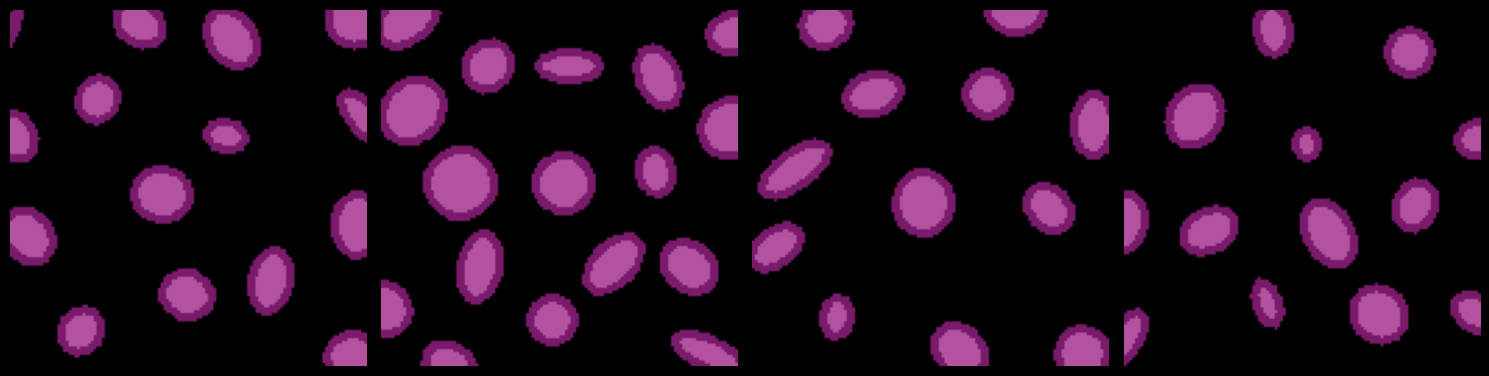

In [24]:
show_images(perlin_test_set[:4])
show_images(set_trenning4[:4])
show_images(validaion_set4[:4])

In [25]:
x_test_perlin = preprocess(perlin_test_set)
x_test_normal4 = preprocess(test_set4)
x_val_set4 = preprocess(validaion_set4)
x_training_set4 = preprocess(set_trenning4)

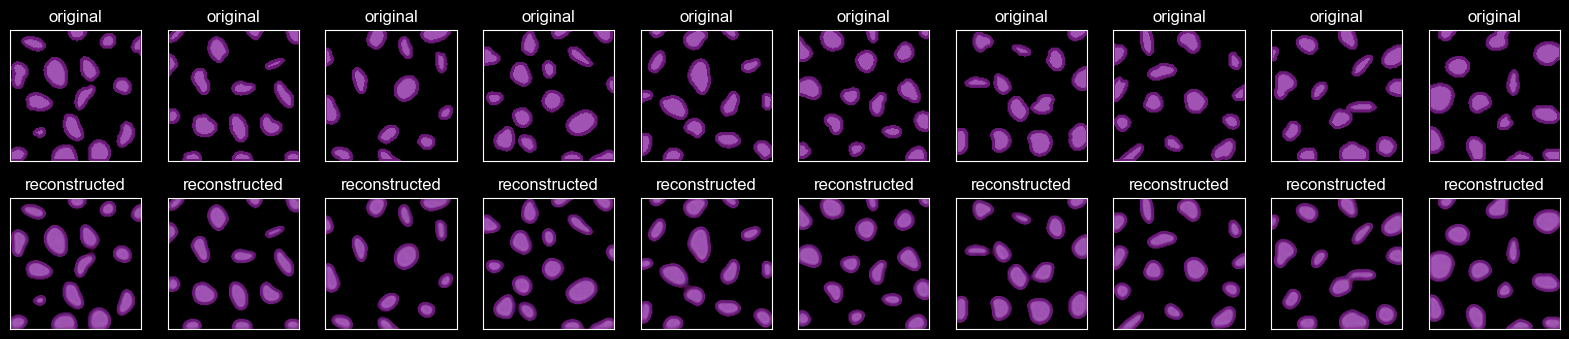

In [26]:
import keras
import numpy as np
from src.models.main import print_diag
from src.visualization.visualize_output import visualize_output
from src.models.encoder_convolutional import Encoder_conv

enkoder = Encoder_conv()

enkoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 'mse'])

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    min_delta=0.0001,
    restore_best_weights=True
)

history = enkoder.fit(
    x_training_set4, x_training_set4,
    epochs=50,
    shuffle=True,
    callbacks=[early_stopping],
    validation_data=(x_val_set4, x_val_set4),
    verbose=1
)
decoded_normal4 = enkoder.predict(x_test_normal4)
decoded_perlin = enkoder.predict(x_test_perlin)

mse_normal = enkoder.evaluate(x_test_normal4, x_test_normal4, verbose=0)[0]
mse_perlin = enkoder.evaluate(x_test_perlin, x_test_perlin, verbose=0)[0]

print(f"\nTrening zakończony po {len(history.history['loss'])} epokach.")
print(f"MSE Normal: {mse_normal:.6f}")
print(f"MSE with perlin noise:  {mse_perlin:.6f}")

visualize_output(x_test_normal4, decoded_normal4, 10)

visualize_output(x_test_perlin, decoded_perlin, 10)

In [27]:
perlin_data = {'Eksperyment': 'MSE with perlin noise', 'Wynik': [mse_perlin]}

mse_dataset = pd.concat([mse_dataset, pd.DataFrame(perlin_data)], ignore_index=True)

mse_dataset

,Eksperyment,Wynik
0,MSE Normal,0.077137
1,MSE Large,0.232328
2,MSE with different color,0.175345
3,MSE with different distribution,0.083466
4,MSE with perlin noise,0.163920


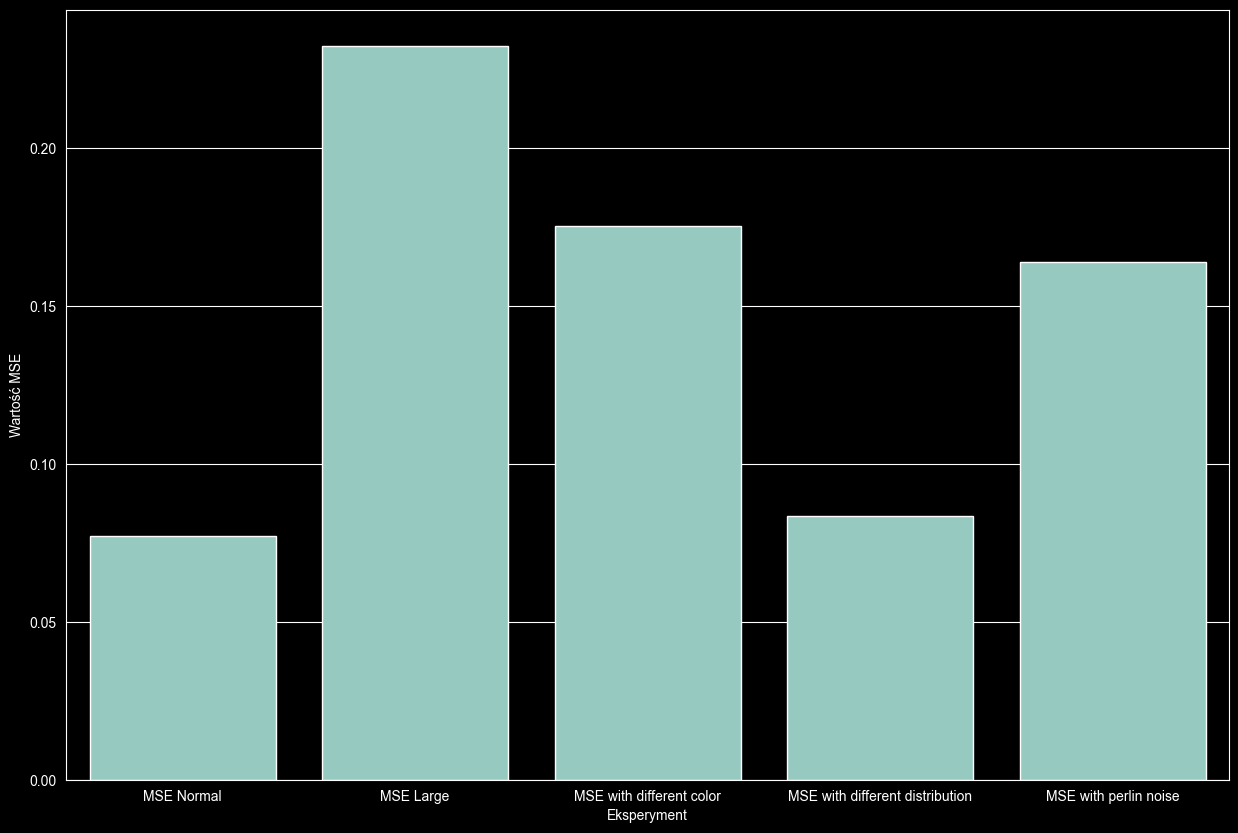

In [28]:
plt.figure(figsize=(15,10))
sns.barplot(data=mse_dataset, y='Wynik',x='Eksperyment')
plt.ylabel("Wartość MSE")
plt.show()

eksperyment

# Eksperymetn piąty
Połączenie wielu różnych parametrów komórek

In [29]:
from builders.simple_generator import generate_image
from src.builders.image_builder import ImageGenerator
from src.utils.classes.config import GenerationConfig
from src.builders.simple_generator import generate_batch
various_conf = (ImageGenerator()
                .with_size(13,15)
                .with_perlin_noise(True)
                .with_clustered_distribution()
                .with_cancer_cells(color=(143,43,172)))
various_conf_set = various_conf.build_batch(2000)

Generated 2 centers
Generated 1 centers
Generated 2 centers
Generated 1 centers
Generated 1 centers
Generated 2 centers
Generated 1 centers
Generated 1 centers
Generated 1 centers
Generated 2 centers
Generated 1 centers
Generated 1 centers
Generated 1 centers
Generated 1 centers
Generated 1 centers
Generated 1 centers
Generated 1 centers
Generated 2 centers
Generated 1 centers
Generated 1 centers
Generated 1 centers
Generated 1 centers
Generated 2 centers
Generated 2 centers
Generated 2 centers
Generated 1 centers
Generated 2 centers
Generated 2 centers
Generated 1 centers
Generated 2 centers
Generated 1 centers
Generated 1 centers
Generated 1 centers
Generated 2 centers
Generated 1 centers
Generated 1 centers
Generated 2 centers
Generated 2 centers
Generated 1 centers


In [30]:
set_trenning5 = generate_batch(5000)
validaion_set5 = generate_batch(1000)
test_set5 = generate_batch(2000)

Generated 16 centers
Generated 16 centers
Generated 16 centers
Generated 14 centers
Generated 19 centers
Generated 16 centers
Generated 13 centers
Generated 14 centers
Generated 15 centers
Generated 14 centers
Generated 15 centers
Generated 14 centers
Generated 15 centers
Generated 14 centers
Generated 15 centers
Generated 17 centers
Generated 16 centers
Generated 16 centers
Generated 14 centers
Generated 15 centers
Generated 14 centers
Generated 14 centers
Generated 15 centers
Generated 16 centers
Generated 16 centers
Generated 18 centers
Generated 16 centers
Generated 14 centers
Generated 13 centers
Generated 16 centers
Generated 17 centers
Generated 14 centers
Generated 15 centers
Generated 15 centers
Generated 15 centers
Generated 13 centers
Generated 16 centers
Generated 15 centers
Generated 13 centers
Generated 15 centers
Generated 15 centers
Generated 13 centers
Generated 14 centers
Generated 16 centers
Generated 14 centers
Generated 14 centers
Generated 13 centers
Generated 13 

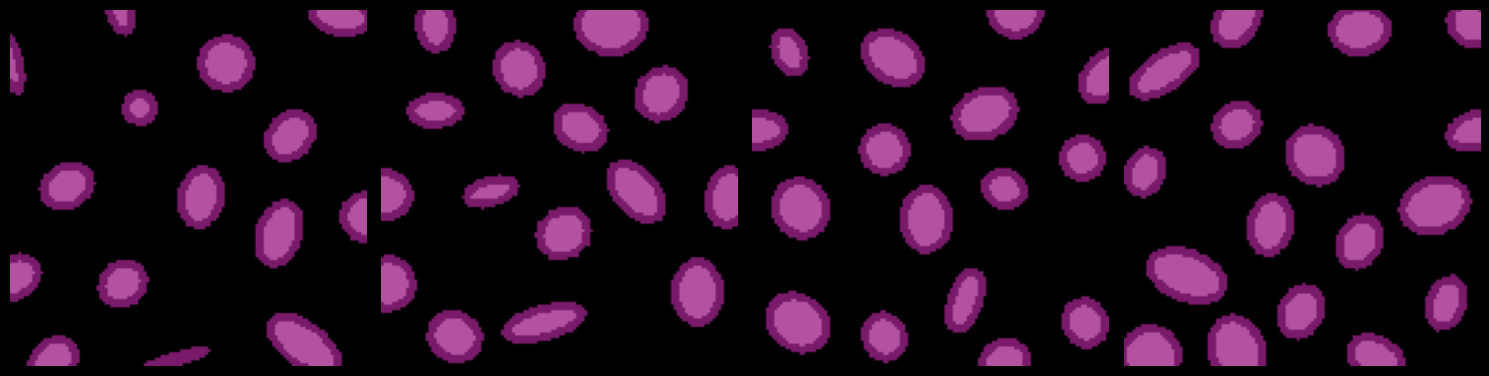

In [31]:
show_images(various_conf_set[:4])
show_images(set_trenning5[:4])
show_images(validaion_set5[:4])

In [32]:
x_test_various = preprocess(various_conf_set)
x_test_normal5 = preprocess(test_set5)
x_val_set5 = preprocess(validaion_set5)
x_training_set5 = preprocess(set_trenning5)

In [33]:
import keras
import numpy as np
from src.models.main import print_diag
from src.visualization.visualize_output import visualize_output
from src.models.encoder_convolutional import Encoder_conv

enkoder = Encoder_conv()

enkoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 'mse'])

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    min_delta=0.0001,
    restore_best_weights=True
)

history = enkoder.fit(
    x_training_set5, x_training_set5,
    epochs=50,
    shuffle=True,
    callbacks=[early_stopping],
    validation_data=(x_val_set5, x_val_set5),
    verbose=1
)
decoded_normal5 = enkoder.predict(x_test_normal5)
decoded_various = enkoder.predict(x_test_various)

mse_normal = enkoder.evaluate(x_test_normal5, x_test_normal5, verbose=0)[0]
mse_various = enkoder.evaluate(x_test_various, x_test_various, verbose=0)[0]

print(f"\nTrening zakończony po {len(history.history['loss'])} epokach.")
print(f"MSE Normal: {mse_normal:.6f}")
print(f"MSE with perlin noise:  {mse_various:.6f}")

visualize_output(x_test_normal5, decoded_normal5, 10)

visualize_output(x_test_various, decoded_various, 10)

InvalidArgumentError: Graph execution error:

Detected at node compile_loss/binary_crossentropy/logistic_loss/mul defined at (most recent call last):
  File "C:\Users\huber\AppData\Local\Programs\Python\Python312\Lib\runpy.py", line 198, in _run_module_as_main

  File "C:\Users\huber\AppData\Local\Programs\Python\Python312\Lib\runpy.py", line 88, in _run_code

  File "C:\Users\huber\PycharmProjects\Projekt_Inzynierski\.venv\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>

  File "C:\Users\huber\PycharmProjects\Projekt_Inzynierski\.venv\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance

  File "C:\Users\huber\PycharmProjects\Projekt_Inzynierski\.venv\Lib\site-packages\ipykernel\kernelapp.py", line 758, in start

  File "C:\Users\huber\PycharmProjects\Projekt_Inzynierski\.venv\Lib\site-packages\tornado\platform\asyncio.py", line 211, in start

  File "C:\Users\huber\AppData\Local\Programs\Python\Python312\Lib\asyncio\base_events.py", line 64

In [ ]:
various_nuclei_data = {'Eksperyment': 'MSE with various configuration', 'Wynik': [mse_various]}

mse_dataset = pd.concat([mse_dataset, pd.DataFrame(various_nuclei_data)], ignore_index=True)

mse_dataset

In [ ]:
plt.figure(figsize=(15,10))
sns.barplot(data=mse_dataset, y='Wynik',x='Eksperyment')
plt.ylabel("Wartość MSE")
plt.show()